       index hemi                     name      color  fs_index  \
0    1639705    L                  unknown  #190519ff      1000   
1    2647065    L                 bankssts  #196428ff      1001   
2   10511485    L  caudalanteriorcingulate  #7d64a0ff      1002   
3       6500    L      caudalmiddlefrontal  #641900ff      1003   
4    3294840    L           corpuscallosum  #784632ff      1004   
..       ...  ...                      ...        ...       ...   
67   1351760    R            supramarginal  #50a014ff      2031   
68   6553700    R              frontalpole  #640064ff      2032   
69  11146310    R             temporalpole  #4614aaff      2033   
70  13145750    R       transversetemporal  #9696c8ff      2034   
71   2146559    R                   insula  #ffc020ff      2035   

                           fs_name  
0                   ctx-lh-unknown  
1                  ctx-lh-bankssts  
2   ctx-lh-caudalanteriorcingulate  
3       ctx-lh-caudalmiddlefrontal  
4         

/tmp/ipykernel_1864/3319699147.py:62: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_roi(


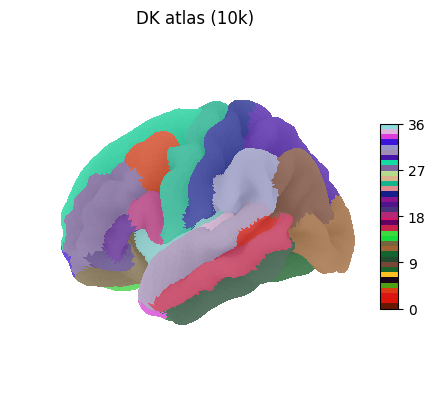

In [11]:
import templateflow.api as tflow
from nilearn.surface import SurfaceImage, load_surf_data
import matplotlib.pyplot as plt
from nilearn.datasets import load_fsaverage_data
from nilearn.plotting import plot_surf_roi, show
import pandas as pd

template = "fsaverage"

# 只使用 10k 密度
density = "10k"

mesh = {}
data = {}
for hemi in ["left", "right"]:
    mesh[hemi] = tflow.get(
        template,
        extension="surf.gii",
        suffix="pial",
        density=density,
        hemi=hemi[0].upper(),
    )

    roi_data = load_surf_data(
        tflow.get(
            template,
            atlas="Desikan2006",
            density=density,
            hemi=hemi[0].upper(),
            extension="label.gii",
        )
    )

    data[hemi] = roi_data

desikan_10k = SurfaceImage(mesh=mesh, data=data)

# 创建单个图
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

fs_density = {
    "3k": "fsaverage4",
    "10k": "fsaverage5",
    "41k": "fsaverage6",
    "164k": "fsaverage",
}

sulcal_depth_map = load_fsaverage_data(
    mesh=fs_density[density], data_type="sulcal"
)

lut = tflow.get(
    template,
    atlas="Desikan2006",
    suffix="dseg",
    extension="tsv",
)
lut= pd.read_csv(lut, sep='\t')

print(lut)

plot_surf_roi(
    roi_map=desikan_10k,
    cmap=lut,
    bg_map=sulcal_depth_map,
    bg_on_data=True,
    title=f"DK atlas ({density})",
    axes=ax,
    view='lateral',  # 设置视角：'lateral', 'medial', 'dorsal', 'ventral', 'anterior', 'posterior'
)

show()